In [1]:
import collections
import matplotlib.pyplot as plt
from IPython import display
import itertools as itr
import numpy as np
from sklearn.metrics import mean_squared_error
from random import randrange
from tabulate import tabulate

import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

from common.const import DATASET_PATH
from common.util import *
from common.optimise import OptimiserEtaSoftmaxArmihoNorm2Base
from common.ffn_model.minst.ffn_minst_util import MetaData
from common.ffn_model.minst.ffn_minst_optimise import \
    StepCalculatorZhangLambda, StepCalculatorEtaSoftmaxArmihoNorm2, StepCalculatorEtaSoftmaxArmihoNorm1\
    , StepCalculatorEtaSoftmaxArmihoNorm2Base, StepCalculatorEtaSoftmaxArmihoNorm1Base\
        , StepCalculatorZhangSimplified
from common.ffn_model.minst.ffn_minst_relu import MNISTReLU
from common.optimise_v4 import NetLineStepProcessor

from torchvision.datasets import EMNIST
#from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid

import logging

In [2]:
logging.basicConfig(filename="log_convcrity_eminst_epochsd_v3.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s",
                datefmt="%m/%d/%Y %I:%M:%S")


#### MNIST dataset

MNIST dataset is used which contains 60000 28x28 images of handwritten digits from 0 to 9. 

In [3]:
# use it to conver from PIL to torch.Tensor
image_transform = ToTensor()

train_dataset = EMNIST(root=DATASET_PATH, split='letters', train=True, download=True, transform=image_transform)
test_dataset = EMNIST(root=DATASET_PATH, split='letters', train=False, download=True, transform=image_transform)

In [4]:
BATCH_SIZE = 64 #128 #128 #64 #

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
)

Data example:

In [5]:
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.1
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

INPUT_DIM = 28 * 28
OUTPUT_DIM = 26 #26  # num of classes

INPUT_WIDTH, HIDDEN_WIDTH = 1000, 400 #2000, 800 #1024, 128 #1000, 400 #500, 200 #1000, 400 #500, 200 #250, 100

lb, lw = 1e-2, 7.5 #1e-2,1,1 #1e-2, 1e-2, 1
meta = MetaData(input_dim = INPUT_DIM, input_width = INPUT_WIDTH, hidden_width = HIDDEN_WIDTH, output_dim = OUTPUT_DIM\
                , batch_size = BATCH_SIZE, lb = lb, lw = lw)

DEVICE = 'cpu' #torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


##### UTILS

In [6]:
def visualise():
    # visualize all together
    display.clear_output()
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    axes[0].set_title('Loss (cross-entropy)')
    axes[0].plot(HISTORY_PARAMS['train_loss'], label='Train Loss')
    axes[0].plot(HISTORY_PARAMS['test_loss'], label='Test Loss')
    axes[0].grid()
    axes[0].legend(fontsize=20)
    
    axes[1].set_title('Accuracy')
    axes[1].plot(HISTORY_PARAMS['train_accuracy'], label='Train Accuracy')
    axes[1].plot(HISTORY_PARAMS['test_accuracy'], label='Test Accuracy')
    axes[1].grid()
    axes[1].legend(fontsize=20)

    fig2, ax2 = plt.subplots(1, 1, figsize=(20, 6))
    ax2.set_title('Train-step eta')
    ax2.plot(HISTORY_PARAMS['train_eta']) #, label='Train-step eta'
    ax2.grid()
    #ax2.legend(fontsize=20)    
    
    plt.show()

HISTORY_PARAMS = collections.defaultdict(list)

In [7]:
HISTORY_NORM1L = collections.defaultdict(list)
HISTORY_NORM2L = collections.defaultdict(list)
#HISTORY_NORM1S = collections.defaultdict(list)
HISTORY_NORM2S = collections.defaultdict(list)
HISTORY_ZHS = collections.defaultdict(list)
#HISTORY_ZHL = collections.defaultdict(list)
HISTORY_OPTADA = collections.defaultdict(list)
HISTORY_OPTFIX = collections.defaultdict(list)

#### Compare optimisers

In [8]:
def print_comparison(low, high):
    #start_epoch, finish_epoch = 10, 20
    display.clear_output()
    fig, axes = plt.subplots(2, 1, figsize=(12, 16))
    axes[0].set_title('Loss (Cross Entropy)')
    #axes[0].set_xlim(start_epoch-1, finish_epoch)
    #axes[0].plot(HISTORY_NORM1['train_loss'][2:40], color='g', ls='dotted', alpha=.5, label='Train norm1')
    #axes[0].plot(HISTORY_NORM2['train_loss'][2:40], color='b', ls='dotted', alpha=.5, label='Train norm2')
    #axes[0].plot(HISTORY_ZHS['train_loss'][2:40], color='r', ls='dotted', alpha=.5, label='Train Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['train_loss'][2:40], color='orange', ls='dotted', alpha=.5, label='Train Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['train_loss'][2:40], color='brown', ls='dotted', alpha=.5, label='Train direct Zhang-lambda')
    axes[0].plot(HISTORY_NORM1L['test_loss'][low:high], color='g',alpha=.5, label='Net-line norm1 NTK')
    axes[0].plot(HISTORY_NORM2L['test_loss'][low:high], color='b',alpha=.5, label='Net-line norm2 NTK')
    #axes[0].plot(HISTORY_NORM1S['test_loss'][low:high], color='g', alpha=.5, label='Test norm1-simple')
    axes[0].plot(HISTORY_NORM2S['test_loss'][low:high], color='b', ls='dotted', alpha=.5, label='Net-line norm2 2-step')    
    axes[0].plot(HISTORY_ZHS['test_loss'][low:high], color='r', alpha=.5, label='Straight-line')
    axes[0].plot(HISTORY_OPTADA['test_loss'][low:high], color='orange', alpha=.5, label='Straight-line optimiser')
    axes[0].plot(HISTORY_OPTFIX['test_loss'][low:high], color='grey', alpha=.5, label='Nesterov-fix optimiser')
    axes[0].grid()
    axes[0].legend()
    axes[0].set_xlabel("Epoch (series of gradient descent steps)")
    axes[0].set_ylabel("Loss value")

    axes[1].set_title('Accuracy')
    #axes[1].set_xlim(10, 20)
    #axes[1].plot(HISTORY_NORM1['train_accuracy'][2:40], color='g', alpha=.5, ls='dotted', label='Train norm1')
    #axes[1].plot(HISTORY_NORM2['train_accuracy'][2:40], color='b', alpha=.5, ls='dotted', label='Train norm2')
    #axes[1].plot(HISTORY_ZHS['train_accuracy'][2:40], color='r', alpha=.5, ls='dotted', label='Train Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['train_accuracy'][2:40], color='orange', alpha=.5, ls='dotted', label='Train Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['train_accuracy'][2:40], color='brown', alpha=.5, ls='dotted', label='Train direct Zhang-lambda')
    axes[1].plot(HISTORY_NORM1L['test_accuracy'][low:high], color='g', alpha=.5, label='Net-line norm1 NTK')
    axes[1].plot(HISTORY_NORM2L['test_accuracy'][low:high], color='b', alpha=.5, label='Net-line norm2 NTK')
    #axes[1].plot(HISTORY_NORM1S['test_accuracy'][low:high], color='g', alpha=.5, label='Test norm1-simple')
    axes[1].plot(HISTORY_NORM2S['test_accuracy'][low:high], color='b', ls='dotted', alpha=.5, label='Net-line norm2 2-step')
    axes[1].plot(HISTORY_ZHS['test_accuracy'][low:high], color='r', alpha=.5, label='Straight-line')
    axes[1].plot(HISTORY_OPTADA['test_accuracy'][low:high], color='orange', alpha=.5, label='Straight-line optimiser')
    axes[1].plot(HISTORY_OPTFIX['test_accuracy'][low:high], color='grey', alpha=.5, label='Nesterov-fix optimiser')
    axes[1].grid()
    axes[1].legend()
    axes[1].set_xlabel("Epoch (series of gradient descent steps)")
    axes[1].set_ylabel("Accuracy value")

    #fig.tight_layout()
    #fig.subplots_adjust(top=0.95)
    dummy=fig.suptitle("Comparison for the same FFN-structure for different optimisers")

    plt.show()

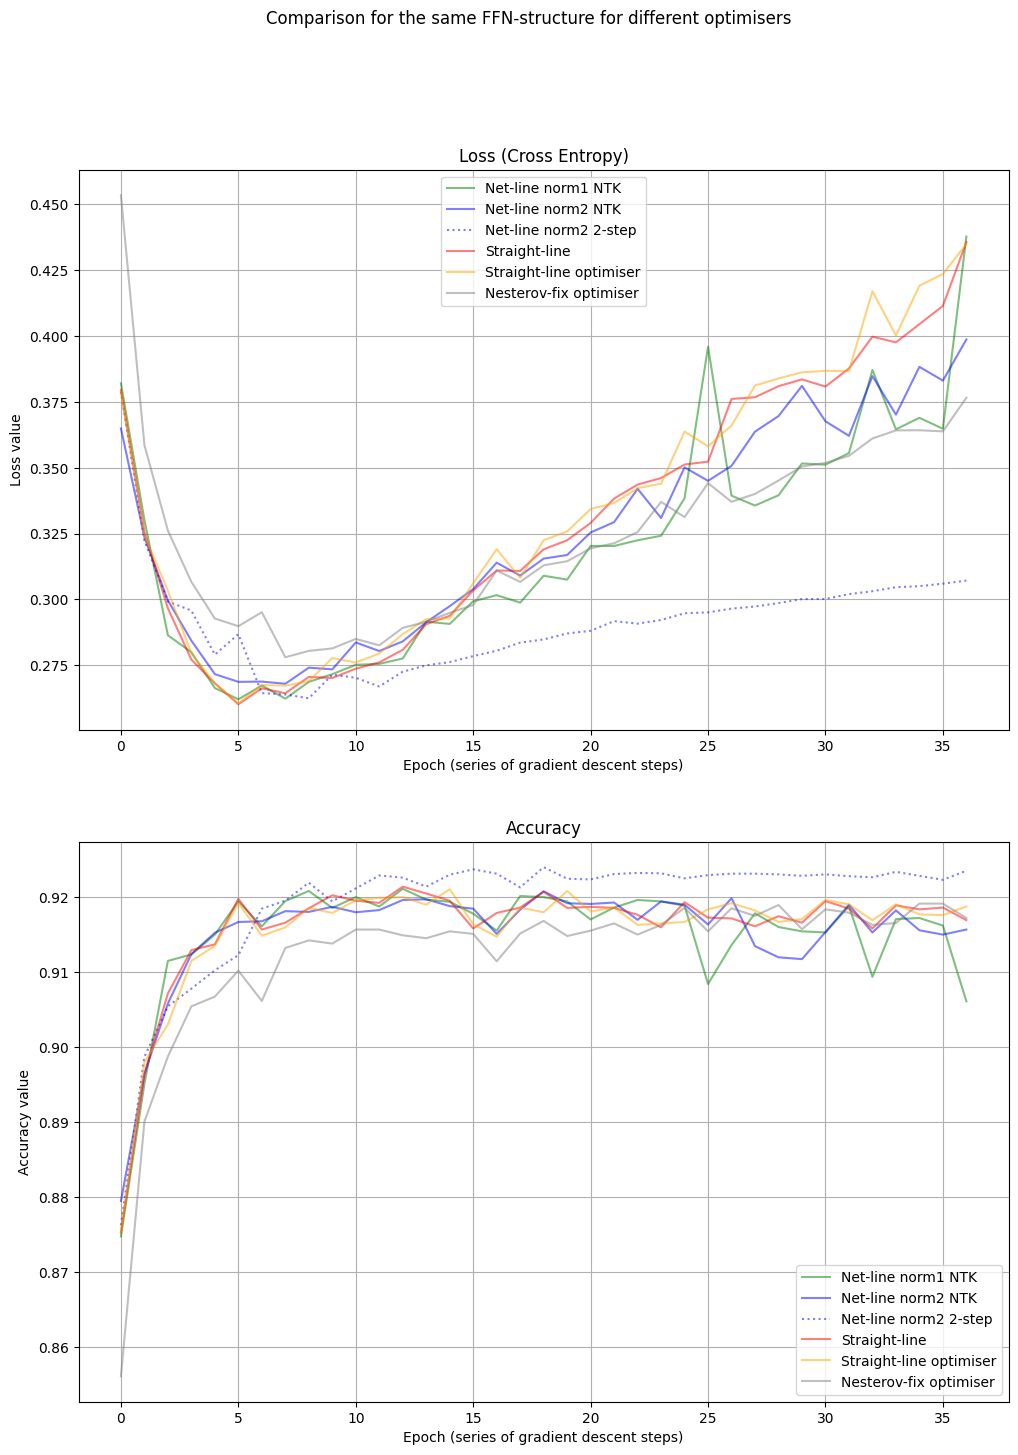

Norm2=0.9235576923076924, Straight line=0.9187980769230769, beta_coeff=3.2


In [ ]:
def test_loop(testNet, test_loss_meter, test_accuracy_meter):
    for test_batch in test_dataloader:
        images, labels_raw = test_batch
        labels = labels_raw - 1
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            batch_size = images.shape[0]
            xx = images.view(batch_size, -1)
            logits = testNet.forward_(xx)

            zz_logits = np.transpose(logits.detach().cpu().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(calculate_accuracy(prediction, labels))

NUM_EPOCH = 50

#results = []
#head = ["type", "loss", "accuracy"]

meta = MetaData(input_dim = INPUT_DIM, input_width = INPUT_WIDTH, hidden_width = HIDDEN_WIDTH, output_dim = OUTPUT_DIM\
                , batch_size = BATCH_SIZE, lb = 0.005, lw = 5.0, device=DEVICE)

stepCalcZhL = StepCalculatorZhangLambda(meta)
stepCalcZhS = StepCalculatorZhangSimplified(meta)
stepCalcSoftmaxL2 = StepCalculatorEtaSoftmaxArmihoNorm2(meta)
stepCalcSoftmaxL1 = StepCalculatorEtaSoftmaxArmihoNorm1(meta)
stepCalcSoftmaxS2 = OptimiserEtaSoftmaxArmihoNorm2Base(meta, DEVICE)
stepCalcSoftmaxS2.check_dropout = False
stepCalcSoftmaxS2.criterion = nn.CrossEntropyLoss(reduction='sum')
stepCalcSoftmaxS1 = StepCalculatorEtaSoftmaxArmihoNorm1Base(meta)

testZhS = MNISTReLU(meta)
testZhS.set_log_level("info")
testZhS.set_slopes(slope_plus, slope_minus)
testZhS.init_weights(cb, cw)
testZhS.to(DEVICE)
testZhS.save_txt("tmp")

testNorm1L = MNISTReLU(meta)
testNorm1L.set_slopes(slope_plus, slope_minus)
testNorm1L.init_weights_txt('tmp', DEVICE)
testNorm1L.to(DEVICE)

testNorm2L = MNISTReLU(meta)
testNorm2L.set_slopes(slope_plus, slope_minus)
testNorm2L.init_weights_txt('tmp', DEVICE)
testNorm2L.to(DEVICE)

testNorm2S = MNISTReLU(meta)
testNorm2S.set_slopes(slope_plus, slope_minus)
testNorm2S.init_weights_txt('tmp', DEVICE)
testNorm2S.to(DEVICE)
testNorm2S.train(False)
stepProcessor = NetLineStepProcessor(testNorm2S, nn.CrossEntropyLoss(), meta, DEVICE)
stepProcessor.c1 = 0.05
stepProcessor.eta0 = 0.0001 #0.0000025 #0.000001
stepProcessor.beta = 0.1
stepProcessor.iter_max = 2
stepProcessor.momentum_gradient_smoothing_coefficient = 0.0 #10.0
step_params = {}

testOptada = MNISTReLU(meta)
testOptada.set_slopes(slope_plus, slope_minus)
testOptada.init_weights_txt('tmp', DEVICE)
testOptada.to(DEVICE)
loss_fn = nn.CrossEntropyLoss(reduction='sum')
optimizer = optim.SGD(testOptada.parameters(), lr=1e-2)

testOptfix = MNISTReLU(meta)
testOptfix.set_slopes(slope_plus, slope_minus)
testOptfix.init_weights_txt('tmp', DEVICE)
testOptfix.to(DEVICE)
loss_fnFix = nn.CrossEntropyLoss() #The version gives 0-accuracy with reduction='sum'
optimizerFix = optim.SGD(testOptfix.parameters(), lr=1e-2, momentum=0.9, nesterov=True)

beta_coeff = 0.1
for epoch in range(NUM_EPOCH):

    loss_data = HISTORY_NORM2S['test_loss']
    if len(loss_data) > 1 and ((loss_data[-2]-loss_data[-1])/loss_data[-1]) < -0.01:
        beta_coeff = beta_coeff * 2.0
    stepProcessor.beta = beta_coeff

    for train_batch in train_dataloader:
        images, labels_raw = train_batch
        labels = labels_raw - 1
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        batch_size = images.shape[0]
        xx = images.view(batch_size, -1)

        logging.info("##Step with straight-line")
        with torch.no_grad():
            logitsZhS = testZhS.forward_(xx)
        etaZhS, _ = stepCalcZhS.step(testZhS, logitsZhS.detach().cpu().numpy(), labels, xx)

        logging.info("##Step with net-line norm2 NTK version")
        with torch.no_grad():
            logits2L = testNorm2L.forward_(xx)
        eta2L, _ = stepCalcSoftmaxL2.step(testNorm2L, logits2L.detach().cpu().numpy(), labels, xx)

        logging.info("##Step with net-line norm1 NTK version")
        with torch.no_grad():
            logits1L = testNorm1L.forward_(xx)
        eta1L, _ = stepCalcSoftmaxL1.step(testNorm1L, logits1L.detach().cpu().numpy(), labels, xx)

        logging.info("##Step with net-line norm2 2-step versiob")
        step_result = stepProcessor.step(labels, xx, momentum=0.9, nesterov=True, step_params=step_params)

        logging.info("##Step with SGD-optimiser straight-line step")
        optimizer.zero_grad()
        logitsOptada = testOptada.forward_(xx)
        lossOptada = loss_fn(logitsOptada, labels)
        lossOptada.backward()
        etaOptada = stepCalcZhS.calc_eta(testOptada, lossOptada.item())
        optimizer.param_groups[0]['lr'] = etaOptada
        optimizer.step()

        logging.info("##--==Step with SGD-optimiser fixed step==--")
        optimizerFix.zero_grad()
        logitsOptfix = testOptfix.forward_(xx)
        lossOptfix = loss_fnFix(logitsOptfix, labels)
        lossOptfix.backward()
        optimizerFix.step()

    # testing loop
    test_loss1L_meter, test_accuracy1L_meter = AverageMeter(), AverageMeter(),
    test_loop(testNorm1L, test_loss1L_meter, test_accuracy1L_meter)
    HISTORY_NORM1L['test_loss'].append(test_loss1L_meter.avg)
    HISTORY_NORM1L['test_accuracy'].append(test_accuracy1L_meter.avg)

    test_loss2L_meter, test_accuracy2L_meter = AverageMeter(), AverageMeter(),
    test_loop(testNorm2L, test_loss2L_meter, test_accuracy2L_meter)
    HISTORY_NORM2L['test_loss'].append(test_loss2L_meter.avg)
    HISTORY_NORM2L['test_accuracy'].append(test_accuracy2L_meter.avg)
        
    test_loss2S_meter, test_accuracy2S_meter = AverageMeter(), AverageMeter(),
    test_loop(testNorm2S, test_loss2S_meter, test_accuracy2S_meter)
    HISTORY_NORM2S['test_loss'].append(test_loss2S_meter.avg)
    HISTORY_NORM2S['test_accuracy'].append(test_accuracy2S_meter.avg)    

    test_lossZhs_meter, test_accuracyZhs_meter = AverageMeter(), AverageMeter(),
    test_loop(testZhS, test_lossZhs_meter, test_accuracyZhs_meter)
    HISTORY_ZHS['test_loss'].append(test_lossZhs_meter.avg)
    HISTORY_ZHS['test_accuracy'].append(test_accuracyZhs_meter.avg)

    test_lossOptada_meter, test_accuracyOptada_meter = AverageMeter(), AverageMeter(),
    test_loop(testOptada, test_lossOptada_meter, test_accuracyOptada_meter)
    HISTORY_OPTADA['test_loss'].append(test_lossOptada_meter.avg)
    HISTORY_OPTADA['test_accuracy'].append(test_accuracyOptada_meter.avg)

    test_lossOptfix_meter, test_accuracyOptfix_meter = AverageMeter(), AverageMeter(),
    test_loop(testOptfix, test_lossOptfix_meter, test_accuracyOptfix_meter)
    HISTORY_OPTFIX['test_loss'].append(test_lossOptfix_meter.avg)
    HISTORY_OPTFIX['test_accuracy'].append(test_accuracyOptfix_meter.avg)    
    
    print_comparison(0, 100)

    print("Norm2={}, Straight line={}, beta_coeff={}"\
          .format(HISTORY_NORM2S['test_accuracy'][-1], HISTORY_OPTADA['test_accuracy'][-1], beta_coeff))


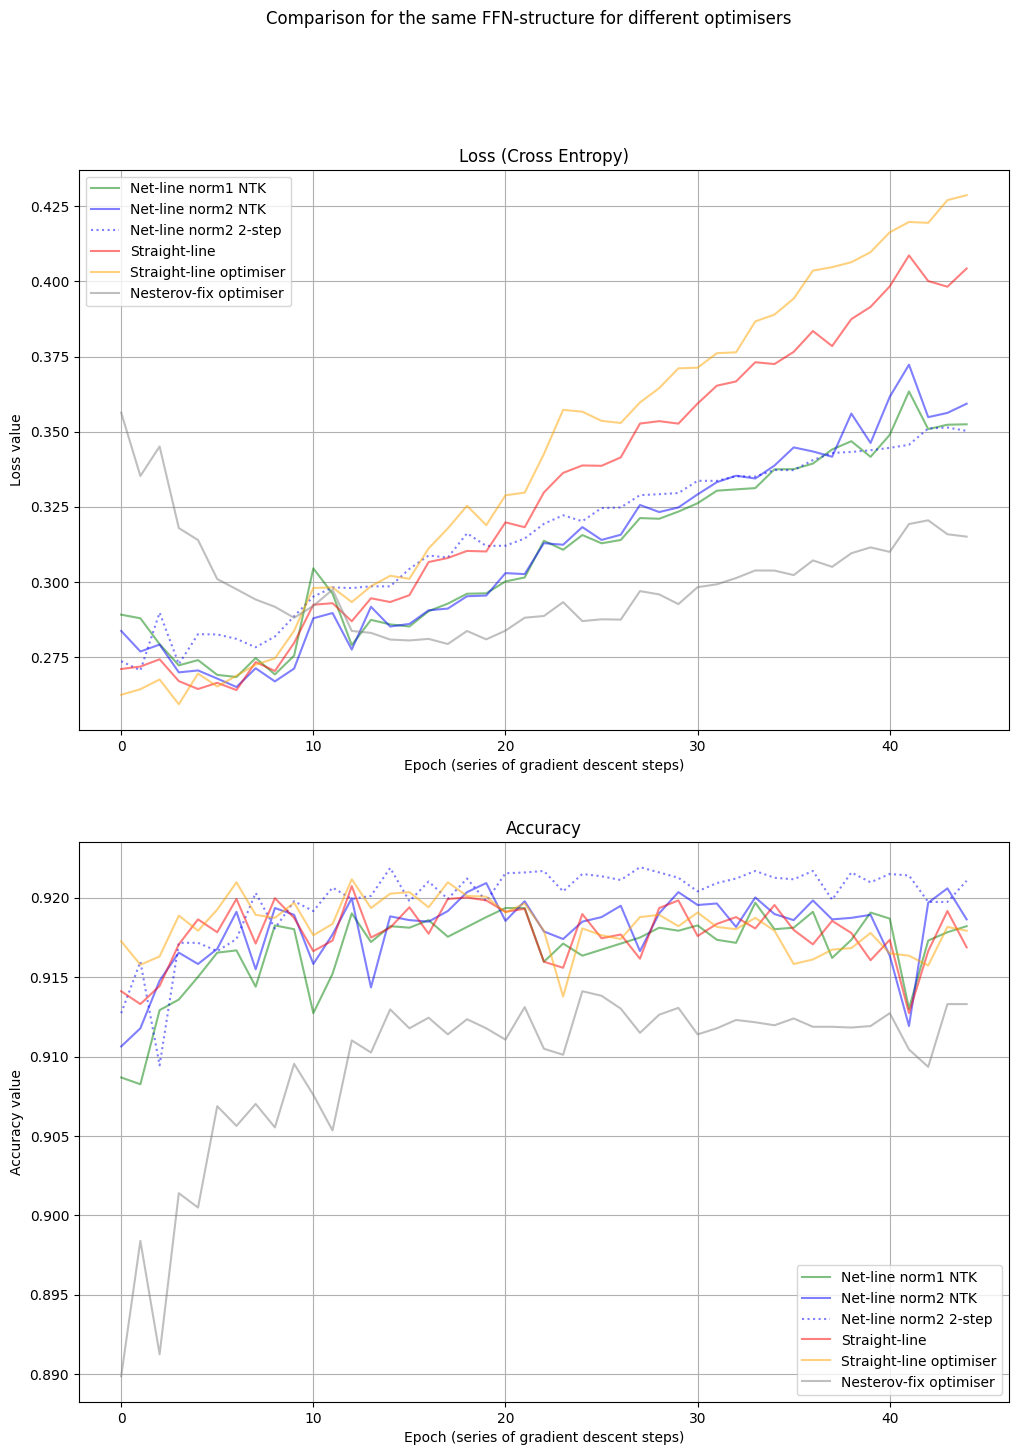

In [19]:
print_comparison(5, 100)

In [20]:
print(HISTORY_NORM1S['test_accuracy'][-1], HISTORY_NORM2S['test_accuracy'][-1])

NameError: name 'HISTORY_NORM1S' is not defined